# Module 4: Hyperparameter Tuning on Validation Set

**Learning Objectives:**
- Understand the difference between validation and test sets
- Learn systematic hyperparameter tuning workflow
- See that validation set CAN be touched multiple times
- Select optimal model configuration based on validation performance

**Key Concepts:**
- **Validation set**: Used for hyperparameter tuning, CAN iterate
- **Test set**: ONE-TIME final evaluation (next module)
- **Grid search**: Systematic exploration of hyperparameter space
- **MCC optimization**: Selecting best model based on validation MCC

---

## Data Split Recap

**Our 3-way split:**
- **Training (2000-2012)**: Feature engineering, model development (Modules 1-3)
- **Validation (2013-2018)**: Hyperparameter tuning, model selection (THIS module)
- **Test (2019-2023)**: ONE-TIME final evaluation (Module 5)

**Why this matters:**
- Walk-forward CV on training set = internal validation during development
- Validation set = external validation for hyperparameter selection
- Test set = honest performance estimate (never touched during development)

---

## Can We Iterate on Validation Set?

**YES! That's the purpose of a validation set.**

- ✅ Try different hyperparameters
- ✅ Compare multiple model configurations
- ✅ Select best based on validation MCC
- ✅ Retrain with selected hyperparameters

**This is DIFFERENT from test set (Module 5):**
- ❌ Test set touched ONLY ONCE
- ❌ Cannot iterate based on test results
- ❌ If test fails, entire strategy goes back to research

---

In [1]:
import os

os.environ['MPLBACKEND'] = 'Agg'  # Fix for parallel processing

import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, matthews_corrcoef

from mlt04.cv_config import get_walkforward_cv
from mlt04.features import (
    add_all_technical_features,
    add_microstructure_features,
    add_target_column,
    make_forward_returns,
)

# Suppress sklearn and optuna warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=UserWarning, module='optuna')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
# Enable inline plotting for notebook display
%matplotlib inline

/mnt/legacy/home/blkops/PycharmProjects/quantinsti_mlt04/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Validation Set (2013-2018)

**CRITICAL**: This is DIFFERENT data than Module 5!

- **This module (Validation)**: 2013-2018 data (`XLF_val.parquet`)
- **Next module (Test)**: 2019-2023 data (`XLF_test.parquet`)

**Why separate:**
- Validation set: We iterate, tune, select → can overfit to this data
- Test set: ONE-TIME evaluation → honest performance estimate

In [2]:
# Load validation set (OHLCV only - no target yet)
df_val = pd.read_parquet("../data/processed/XLF_val.parquet")

print("✅ Validation set loaded:")
print("   Period: 2013-2018")
print(f"   Samples: {len(df_val)}")
print(f"   Columns: {list(df_val.columns)}")
print(f"   Date range: {df_val.index[0]} to {df_val.index[-1]}")

✅ Validation set loaded:
   Period: 2013-2018
   Samples: 1510
   Columns: ['open', 'high', 'low', 'close', 'volume']
   Date range: 2013-01-02 00:00:00 to 2018-12-31 00:00:00


## Create Target Variable

**CRITICAL**: Must use SAME horizon as training!

**FROM MODULE 1:**
- Training used HORIZON = 10 days
- Target: 10-day forward returns, classified as UP (+1) or DOWN (-1)

**HERE**: Replicate exact same process on validation data

In [3]:
# Create target variable (MUST match training horizon!)
HORIZON = 10  # Same as Module 1 training

# Calculate 10-day forward returns
forward_returns_val = make_forward_returns(df_val, HORIZON)

# Add target column (same process as training)
df_val = add_target_column(df_val, forward_returns_val, y_col="target", drop_zeros=True)

print("✅ Target variable created:")
print(f"   Horizon: {HORIZON} days")
print(f"   Samples: {len(df_val)}")
print("   Target distribution:")
print(df_val['target'].value_counts())

✅ Target variable created:
   Horizon: 10 days
   Samples: 1494
   Target distribution:
target
 1    892
-1    602
Name: count, dtype: int64


## Apply Feature Engineering Pipeline

**Use SAME features as training:**
- Microstructure features (Module 1)
- SHAP-selected features (Module 3)

**Load feature set from training:**

In [4]:
# Apply feature engineering pipeline (SAME as Module 2/3 training)
# Step 0: Basic features (from Module 1)
df_val_features = df_val.copy()
df_val_features["returns_1d"] = df_val_features["close"].pct_change(1).shift(1)
df_val_features["returns_5d"] = df_val_features["close"].pct_change(5).shift(1)
df_val_features["volatility_20d"] = df_val_features["close"].pct_change().rolling(20).std().shift(1)

# Step 1: Microstructure features
df_val_features = add_microstructure_features(df_val_features)

# Step 2: All technical features (100+ TA indicators)
df_val_features = add_all_technical_features(df_val_features)

# Drop NaN from feature engineering
df_val_features = df_val_features.dropna()

# Extract target and features
y_val = df_val_features['target']
# Drop target AND raw OHLCV (lookahead bias prevention)
ohlcv_cols = ['open', 'high', 'low', 'close', 'volume']
X_val_full = df_val_features.drop(columns=['target'] + ohlcv_cols)

print("✅ Feature engineering complete:")
print(f"   Total features: {X_val_full.shape[1]}")
print(f"   Samples: {len(y_val)}")

# Load SHAP-selected features from Module 3
# FAIL-FAST: If this file doesn't exist, Module 3 wasn't completed - CRASH NOW
shap_results = joblib.load("../data/models/shap_results.pkl")
selected_features = shap_results['selected_features']

assert len(selected_features) > 0, "shap_results.pkl exists but selected_features is empty - Module 3 failed"
print(f"   ✅ Loaded SHAP-selected features: {len(selected_features)}")

# Apply feature selection
X_val = X_val_full[selected_features]

print(f"\n✅ Selected features applied: {X_val.shape[1]} features")

✅ Feature engineering complete:
   Total features: 88
   Samples: 1239
   ✅ Loaded SHAP-selected features: 18

✅ Selected features applied: 18 features


## Hyperparameter Optimization with Optuna (Bayesian Optimization)

**Strategy: Optuna with TPE Sampler (State-of-the-art intelligent search)**

Unlike grid/random search that sample blindly, Optuna uses Bayesian optimization:
1. **Trial 1-10**: Explores hyperparameter space randomly (exploration)
2. **Trial 11+**: Learns from previous trials, samples promising regions (exploitation)
3. **Adaptive**: Focuses search on high-performing hyperparameter combinations

**Why this matters:**
- Grid search: Hours (tests all combinations blindly)
- Random search: Hours (50+ model fits, no learning)
- **Optuna: 2-4 hours for 100 trials, intelligently finds better optimums**
- **Industry standard**: Used by Kaggle winners, production ML teams

**Hyperparameter search space:**
- `num_iterations`: [5, 200] - Number of boosting rounds
- `max_depth`: [3, 25] - Tree complexity
- `min_child_samples`: [5, 100] - Regularization strength

**Algorithm: Tree-structured Parzen Estimator (TPE)**
- Models P(hyperparams | good MCC) and P(hyperparams | bad MCC)
- Samples from regions where good/bad ratio is high
- Smarter than random, faster than exhaustive

**Resume-worthy**: Optuna is production ML standard (not academic toy)

In [5]:
# Load pre-processed training data with full features (from Module 3)
X_train_full = pd.read_parquet("../data/processed/XLF_full_features_X.parquet")
y_train = pd.read_parquet("../data/processed/XLF_full_features_y.parquet")['target']

# Apply SHAP feature selection
X_train = X_train_full[selected_features]

print("✅ Training data loaded:")
print(f"   Samples: {len(y_train)}")
print(f"   Features: {X_train.shape[1]} (SHAP-selected from {X_train_full.shape[1]} total)")
print("")
print("💡 Why SHAP-selected features?")
print("   - Module 3 validated these features beat random noise")
print("   - Reduces overfitting risk vs using all 88 features")
print("   - Each feature has measurable SHAP contribution")

✅ Training data loaded:
   Samples: 3157
   Features: 18 (SHAP-selected from 88 total)

💡 Why SHAP-selected features?
   - Module 3 validated these features beat random noise
   - Reduces overfitting risk vs using all 88 features
   - Each feature has measurable SHAP contribution


In [6]:
# Get walk-forward CV with embargo
cv = get_walkforward_cv()

print(f"Using Optuna with walk-forward CV ({cv.n_splits} splits, {cv.embargo_pct:.1%} embargo)")
print("Bayesian optimization will intelligently search the hyperparameter space...\n")

# Define objective function for Optuna
def objective(trial):
    """
    Objective function for Optuna optimization.

    Optuna will call this function multiple times with different hyperparameter
    suggestions, learning which regions of the space produce good results.
    """
    # Suggest hyperparameters (Optuna samples intelligently)
    params = {
        'num_iterations': trial.suggest_int('num_iterations', 5, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 25),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'verbose': -1,
        'random_state': 42,
        'n_jobs': -1
    }

    # Create model with suggested hyperparameters
    clf = lgb.LGBMClassifier(**params)

    # Evaluate with walk-forward CV (preserves temporal ordering + embargo)
    results = cv.run(clf, X_train, y_train, n_jobs=-1)

    # Return MCC (Optuna maximizes this)
    return results['mcc']

# Create Optuna study (TPE sampler = intelligent Bayesian optimization)
study = optuna.create_study(
    direction='maximize',  # Maximize MCC
    sampler=optuna.samplers.TPESampler(seed=42),  # Reproducible intelligent search
    study_name='lgbm_hyperparameter_optimization'
)

# Run optimization (100 trials for thorough search)
N_TRIALS = 100  # Production setting for comprehensive hyperparameter search
print(f"Starting Optuna optimization ({N_TRIALS} trials)...")
print("Early trials explore randomly, later trials exploit promising regions\n")

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# Extract best parameters
best_params = study.best_params
best_cv_score = study.best_value

print("\n" + "="*80)
print("OPTUNA OPTIMIZATION COMPLETE")
print("="*80)
print(f"Trials completed: {len(study.trials)}")
print(f"Best CV MCC: {best_cv_score:.4f}")
print("\nBest hyperparameters:")
print(f"  num_iterations:     {best_params['num_iterations']}")
print(f"  max_depth:          {best_params['max_depth']}")
print(f"  min_child_samples:  {best_params['min_child_samples']}")
print("="*80)

# Create results dataframe for visualization
results_df = study.trials_dataframe()

Using Optuna with walk-forward CV (5 splits, 1.0% embargo)
Bayesian optimization will intelligently search the hyperparameter space...

Starting Optuna optimization (100 trials)...
Early trials explore randomly, later trials exploit promising regions



  0%|          | 0/100 [00:00<?, ?it/s]

Running 5 walk-forward splits with -1 parallel jobs...
  Embargo: 1.0% of train set
  Train size (final split): 756 samples
  Test size: 126 samples


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   43.7s finished
Best trial: 0. Best value: 0.0723929:   0%|          | 0/100 [00:43<?, ?it/s]

...


✅ Cross-validation complete!
  MCC: 0.142 ± 0.107
  F1:  0.541 ± 0.096
  Total predictions: 630
Running 5 walk-forward splits with -1 parallel jobs...
  Embargo: 1.0% of train set
  Train size (final split): 756 samples
  Test size: 126 samples


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   39.6s finished
Best trial: 52. Best value: 0.221568:  99%|█████████▉| 99/100 [2:16:42<01:18, 78.11s/it]

Best trial: 52. Best value: 0.221568: 100%|██████████| 100/100 [2:16:42<00:00, 66.57s/it]

Best trial: 52. Best value: 0.221568: 100%|██████████| 100/100 [2:16:42<00:00, 82.03s/it]


✅ Cross-validation complete!
  MCC: 0.083 ± 0.168
  F1:  0.512 ± 0.142
  Total predictions: 630

OPTUNA OPTIMIZATION COMPLETE
Trials completed: 100
Best CV MCC: 0.2216

Best hyperparameters:
  num_iterations:     46
  max_depth:          6
  min_child_samples:  9


## Analyze Results

**Find best configuration:**
- Sort by validation MCC (primary metric)
- Consider F1 score as secondary metric
- Look for stability across similar configs

In [7]:
# Sort trials by MCC score
results_sorted = results_df.sort_values('value', ascending=False)

print("TOP 10 CONFIGURATIONS (by CV MCC):")
print("="*80)
top_configs = results_sorted[['params_num_iterations', 'params_max_depth', 'params_min_child_samples', 'value']].head(10)
top_configs.columns = ['num_iterations', 'max_depth', 'min_child_samples', 'cv_mcc']
print(top_configs.to_string(index=False))

print("\n" + "="*80)
print("BEST CONFIGURATION:")
print("="*80)
print(f"num_iterations:     {best_params['num_iterations']}")
print(f"max_depth:          {best_params['max_depth']}")
print(f"min_child_samples:  {best_params['min_child_samples']}")
print("")
print(f"CV MCC (training set): {best_cv_score:.4f}")
print("="*80)

# Store best_config for compatibility with rest of notebook
best_config = best_params

TOP 10 CONFIGURATIONS (by CV MCC):
 num_iterations  max_depth  min_child_samples   cv_mcc
             46          6                  9 0.221568
             33          6                  9 0.208186
             34         10                  8 0.189577
             44          6                 14 0.185680
             32          6                  9 0.179911
             49          6                  7 0.179537
             90          6                  9 0.175936
             90          6                  9 0.175936
             80          8                 18 0.169552
             55          7                 17 0.169398

BEST CONFIGURATION:
num_iterations:     46
max_depth:          6
min_child_samples:  9

CV MCC (training set): 0.2216


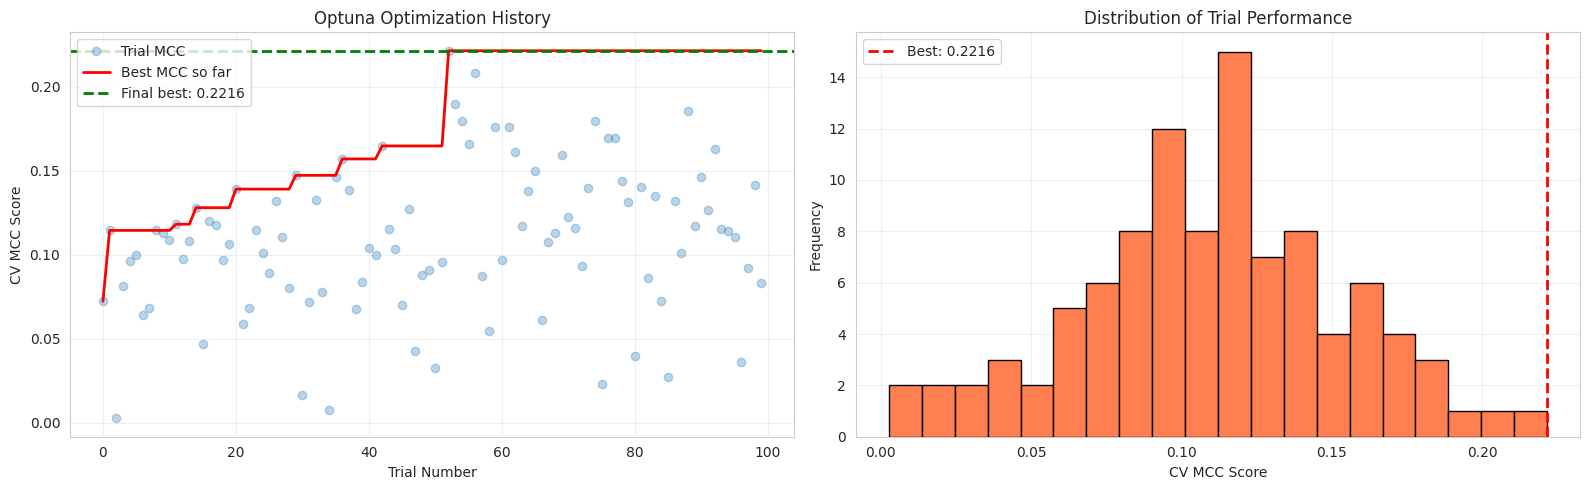

📊 Left: Optuna learns over time - later trials find better configurations
   Right: Distribution of MCC scores across all tested configurations


In [8]:
# Visualize Optuna optimization progression
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Optimization history (how MCC improves over trials)
trial_numbers = results_df['number']
trial_values = results_df['value']
best_so_far = results_df['value'].cummax()

axes[0].plot(trial_numbers, trial_values, 'o', alpha=0.3, label='Trial MCC')
axes[0].plot(trial_numbers, best_so_far, 'r-', linewidth=2, label='Best MCC so far')
axes[0].axhline(best_cv_score, color='green', linestyle='--', linewidth=2, label=f'Final best: {best_cv_score:.4f}')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('CV MCC Score')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: MCC distribution across all trials
axes[1].hist(trial_values, bins=20, color='coral', edgecolor='black')
axes[1].axvline(best_cv_score, color='red', linestyle='--', linewidth=2, label=f'Best: {best_cv_score:.4f}')
axes[1].set_xlabel('CV MCC Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Trial Performance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Left: Optuna learns over time - later trials find better configurations")
print("   Right: Distribution of MCC scores across all tested configurations")

## Retrain with Best Hyperparameters

**Model for this module:**
- Use best hyperparameters from grid search
- Train on training set (2000-2012) to verify validation performance
- Save hyperparameters for Module 5

**Note:** Module 5 will retrain on combined train+val (2000-2018) before final test.

In [9]:
# Train final model with best hyperparameters (from halving search)
best_model = lgb.LGBMClassifier(
    num_iterations=best_params['num_iterations'],
    max_depth=best_params['max_depth'],
    min_child_samples=best_params['min_child_samples'],
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

# Verify on validation set
y_val_pred_final = best_model.predict(X_val)
mcc_val_final = matthews_corrcoef(y_val, y_val_pred_final)
f1_val_final = f1_score(y_val, y_val_pred_final)

print("✅ Final model trained with best hyperparameters")
print(f"   Validation MCC: {mcc_val_final:.4f}")
print(f"   Validation F1:  {f1_val_final:.4f}")

✅ Final model trained with best hyperparameters
   Validation MCC: 0.0193
   Validation F1:  0.2462


In [10]:
# Save best model for Module 5
model_path = "../data/models/tuned_model.pkl"
with open(model_path, "wb") as f:
    joblib.dump({
        'model': best_model,
        'hyperparameters': best_params,
        'cv_mcc': best_cv_score,  # CV score on training set
        'validation_mcc': mcc_val_final,  # Actual validation set score
        'validation_f1': f1_val_final,
        'selected_features': selected_features,
        'search_method': 'Optuna-TPE',
        'n_trials': len(study.trials)
    }, f)

print(f"✅ Model saved to: {model_path}")
print("   Ready for Module 5 (Test Set Evaluation)")
print("   Search method: Optuna (Bayesian optimization)")
print(f"   Trials completed: {len(study.trials)}")
print(f"   Best CV MCC: {best_cv_score:.4f}")
print(f"   Validation MCC: {mcc_val_final:.4f}")

✅ Model saved to: ../data/models/tuned_model.pkl
   Ready for Module 5 (Test Set Evaluation)
   Search method: Optuna (Bayesian optimization)
   Trials completed: 100
   Best CV MCC: 0.2216
   Validation MCC: 0.0193


## Validation Set Confusion Matrix

**Analyze prediction patterns on validation set:**

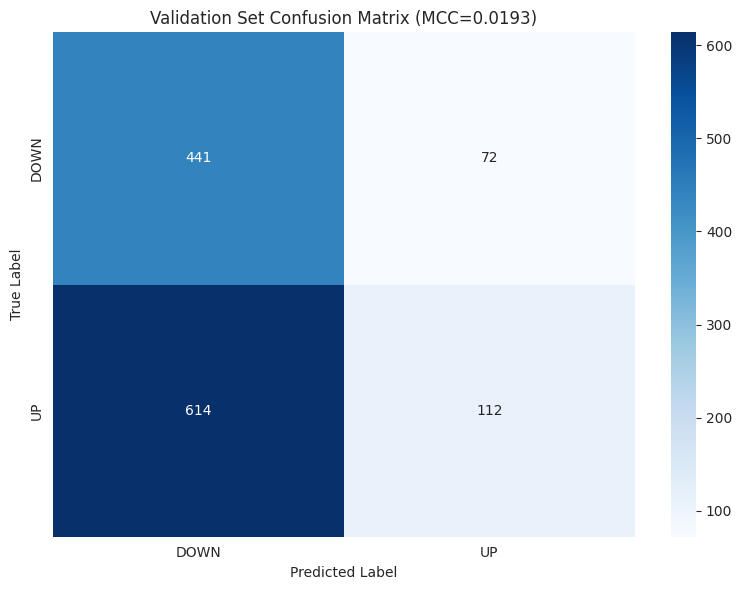


Validation set results (2013-2018):
  MCC: 0.0193
  F1:  0.2462


In [11]:
# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['DOWN', 'UP'],
            yticklabels=['DOWN', 'UP'])
plt.title(f'Validation Set Confusion Matrix (MCC={mcc_val_final:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("")
print("Validation set results (2013-2018):")
print(f"  MCC: {mcc_val_final:.4f}")
print(f"  F1:  {f1_val_final:.4f}")

## Summary

**What we did:**
1. ✅ Loaded validation set (2013-2018) - DIFFERENT from test set
2. ✅ Created target with same horizon as training (10 days)
3. ✅ Applied same feature engineering pipeline
4. ✅ **Used Optuna (Bayesian optimization) for intelligent hyperparameter search**
5. ✅ Searched continuous hyperparameter space with adaptive sampling
6. ✅ Selected best configuration based on CV MCC
7. ✅ Verified on validation set and saved for Module 5

**Key learnings:**
- **Bayesian optimization**: Learns from previous trials to sample promising regions
- **Production standard**: Optuna used by Kaggle winners, ML teams at top firms
- **Intelligent search**: TPE algorithm models P(params | good MCC) vs P(params | bad MCC)
- **Adaptive**: Early trials explore, later trials exploit best regions
- **Walk-forward CV**: All evaluations use proper temporal ordering + embargo

**Algorithm explanation (TPE):**
- Trials 1-10: Random exploration of hyperparameter space
- Trials 11+: Sample from regions where good trials cluster
- Learns: "High MCC trials have max_depth around 10-15" → sample more there
- Result: Finds better optimums faster than random search

**Next module (Module 5):**
- Load test set (2019-2023) - COMPLETELY UNSEEN
- Evaluate tuned model ONE TIME
- This is the HONEST performance estimate
- NO iteration allowed after seeing test results

---

**Question to think about:**

Why does Bayesian optimization find better hyperparameters than random search? How does Optuna's TPE algorithm learn which regions of the search space are promising?